In [1]:
# 忽略警告訊息
import warnings
warnings.filterwarnings("ignore")

# 匯入必要的套件
import matplotlib.pyplot as plt

# 使用 fivethirtyeight 風格，讓圖表更美觀
# plt.style.use('fivethirtyeight')

# 設定字型，確保中文能正常顯示
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei",
    "Microsoft YaHei",
    "SimHei",
    "Arial Unicode MS",
    "DejaVu Sans"
]

# 設定數學字型，確保負號能正常顯示
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["mathtext.fontset"] = "dejavusans"

# Module 3. 監督式學習：分類

## 本章使用的資料集

### `ex3-1.csv`：Iris 鳶尾花資料集
這是一個經典的多元分類資料集，每一筆資料是一朵鳶尾花。

| 欄位 | 說明 |
|---|---|
| `sepal_length` | 花萼長度 |
| `sepal_width` | 花萼寬度 |
| `petal_length` | 花瓣長度 |
| `petal_width` | 花瓣寬度 |
| `species` | 鳶尾花品種，這是多元分類目標 |

### `ex3-2.csv`：寶可夢資料集
本章主要用能力值預測寶可夢是否具有第二屬性。

| 欄位 | 說明 |
|---|---|
| `HP`, `Attack`, `Defense`, `SpecialAtk`, `SpecialDef`, `Speed` | 寶可夢的六個能力值，作為模型特徵 |
| `Type2` | 第二屬性；若不是空值，代表有第二屬性 |
| `Legendary` | 是否為傳奇寶可夢 |
| `Generation` | 世代 |
| `Type1` | 第一屬性 |


In [2]:
# ============================================================
# 1. 匯入套件與讀取資料
# ============================================================

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.multiclass import OneVsOneClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import mean_absolute_error

from sklearn.svm import LinearSVC
from sklearn.svm import SVC

from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestClassifier

from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import RadiusNeighborsClassifier

# 讀取兩個教學資料集
iris_data = pd.read_csv("ex3-1.csv")
pokemon_data = pd.read_csv("ex3-2.csv")

# 這 6 個欄位是本章寶可夢分類範例最常使用的特徵順序
feature_columns = ["HP", "Attack", "Defense", "SpecialAtk", "SpecialDef", "Speed"]

print("Iris 資料筆數與欄位數：")
print(iris_data.shape)

print("Pokemon 資料筆數與欄位數：")
print(pokemon_data.shape)

print("Iris 前 5 筆資料：")
display(iris_data.head())

print("Pokemon 六個能力值的描述統計：")
display(pokemon_data[feature_columns].describe())

Iris 資料筆數與欄位數：
(150, 5)
Pokemon 資料筆數與欄位數：
(894, 12)
Iris 前 5 筆資料：


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Pokemon 六個能力值的描述統計：


,HP,Attack,Defense,SpecialAtk,SpecialDef,Speed
count,894.000000,894.000000,894.000000,894.000000,894.000000,894.000000
mean,69.469799,79.848993,74.420582,73.428412,72.401566,68.241611
std,25.670988,32.691003,31.323902,33.110134,27.963359,29.283795
min,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000
25%,50.000000,55.000000,50.000000,50.000000,50.000000,45.000000
50%,66.000000,75.000000,70.000000,65.000000,70.000000,65.000000
75%,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000
max,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000


## 1. 準備分類任務資料

本章會示範兩種分類任務：

1. **多元分類**：用 Iris 的 4 個花朵特徵預測 `species`。
2. **二元分類**：用寶可夢 6 個能力值預測是否具有第二屬性 `hasType2`。


In [3]:
# ============================================================
# 1. 準備 Iris 多元分類資料與 Pokemon 二元分類資料
# ============================================================

# ---------- Iris：多元分類 ----------
iris = iris_data.copy()

iris_feature_columns = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
X_iris = iris[iris_feature_columns]
y_iris = iris["species"]

X_iris_train, X_iris_test, y_iris_train, y_iris_test = train_test_split(
    X_iris,
    y_iris,
    test_size=0.25,
    random_state=0,
    stratify=y_iris
)

iris_scaler = StandardScaler()
X_iris_train_scaled = iris_scaler.fit_transform(X_iris_train)
X_iris_test_scaled = iris_scaler.transform(X_iris_test)

# ---------- Pokemon：二元分類 ----------
pokemon = pokemon_data.copy()

# Type2 不是空值，代表有第二屬性，標記為 1；否則標記為 0
pokemon["hasType2"] = pokemon["Type2"].notna().astype(int)

X_pokemon = pokemon[feature_columns]
y_pokemon = pokemon["hasType2"]

X_pokemon_train, X_pokemon_test, y_pokemon_train, y_pokemon_test = train_test_split(
    X_pokemon,
    y_pokemon,
    test_size=0.25,
    random_state=0,
    stratify=y_pokemon
)

pokemon_scaler = StandardScaler()
X_pokemon_train_scaled = pokemon_scaler.fit_transform(X_pokemon_train)
X_pokemon_test_scaled = pokemon_scaler.transform(X_pokemon_test)

print("Iris 類別分布：")
display(y_iris.value_counts())

print("Pokemon 是否有第二屬性的類別分布：")
display(y_pokemon.value_counts())

print("Pokemon 使用的特徵順序：")
print(feature_columns)

Iris 類別分布：


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Pokemon 是否有第二屬性的類別分布：


hasType2
1    473
0    421
Name: count, dtype: int64

Pokemon 使用的特徵順序：
['HP', 'Attack', 'Defense', 'SpecialAtk', 'SpecialDef', 'Speed']


## 2. 多元分類器、分類可靠度與 K-fold Cross Validation

這一格示範三件事：

1. **One-vs-Rest（OvR）**：每次把一個類別拿出來，和其他所有類別比較。
2. **One-vs-One（OvO）**：每次只比較兩個類別。
3. **分類可靠度**：觀察 `decision_function()` 與 `predict_proba()` 的輸出。

另外，本章也示範 5-fold cross validation。每一個 fold 都會訓練一次簡單的 Logistic Regression，並列出該 fold 的訓練與驗證準確率。


In [4]:
# ============================================================
# 2. 多元分類器、分類可靠度、K-fold cross validation
# ============================================================

# ---------- One-vs-Rest ----------
ovr_model = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=1.0))
ovr_model.fit(X_iris_train_scaled, y_iris_train)
ovr_pred = ovr_model.predict(X_iris_test_scaled)

# ---------- One-vs-One ----------
ovo_model = OneVsOneClassifier(LogisticRegression(max_iter=1000, C=1.0))
ovo_model.fit(X_iris_train_scaled, y_iris_train)
ovo_pred = ovo_model.predict(X_iris_test_scaled)

print("OvR 測試準確率：", accuracy_score(y_iris_test, ovr_pred))
print("OvO 測試準確率：", accuracy_score(y_iris_test, ovo_pred))

# ---------- 分類結果的可靠度 ----------
# LogisticRegression 可以輸出 decision_function 與 predict_proba
iris_model = LogisticRegression(max_iter=1000, C=1.0)
iris_model.fit(X_iris_train_scaled, y_iris_train)

decision_scores = iris_model.decision_function(X_iris_test_scaled)
predicted_probabilities = iris_model.predict_proba(X_iris_test_scaled)

print("前 3 筆測試資料的 decision_function 分數：")
decision_df = pd.DataFrame(decision_scores[:3], columns=iris_model.classes_)
display(decision_df)

print("前 3 筆測試資料的 predicted probability：")
probability_df = pd.DataFrame(predicted_probabilities[:3], columns=iris_model.classes_)
display(probability_df)

# ---------- 5-fold Cross Validation ----------
print("5-fold cross validation：")

kfold = KFold(n_splits=5, shuffle=True, random_state=0)
fold_number = 1

for train_index, valid_index in kfold.split(X_iris):
    X_fold_train = X_iris.iloc[train_index]
    X_fold_valid = X_iris.iloc[valid_index]
    y_fold_train = y_iris.iloc[train_index]
    y_fold_valid = y_iris.iloc[valid_index]

    fold_scaler = StandardScaler()
    X_fold_train_scaled = fold_scaler.fit_transform(X_fold_train)
    X_fold_valid_scaled = fold_scaler.transform(X_fold_valid)

    fold_model = LogisticRegression(max_iter=1000, C=1.0)
    fold_model.fit(X_fold_train_scaled, y_fold_train)

    train_score = fold_model.score(X_fold_train_scaled, y_fold_train)
    valid_score = fold_model.score(X_fold_valid_scaled, y_fold_valid)

    print("Fold", fold_number, "訓練準確率 =", round(train_score, 4), "驗證準確率 =", round(valid_score, 4))
    fold_number = fold_number + 1

OvR 測試準確率： 0.868421052631579
OvO 測試準確率： 0.9736842105263158
前 3 筆測試資料的 decision_function 分數：


,setosa,versicolor,virginica
0,5.768499,2.210191,-7.978690
1,5.492646,2.528027,-8.020673
2,6.240698,2.038147,-8.278845


前 3 筆測試資料的 predicted probability：


,setosa,versicolor,virginica
0,0.972301,0.027698,1.041052e-06
1,0.950949,0.049050,1.286464e-06
2,0.985263,0.014737,4.872981e-07


5-fold cross validation：
Fold 1 訓練準確率 = 0.9583 驗證準確率 = 1.0
Fold 2 訓練準確率 = 0.975 驗證準確率 = 0.9
Fold 3 訓練準確率 = 0.9667 驗證準確率 = 1.0
Fold 4 訓練準確率 = 0.9667 驗證準確率 = 1.0
Fold 5 訓練準確率 = 0.9833 驗證準確率 = 0.9333


## 3. 邏輯斯迴歸的 Sigmoid 函數

邏輯斯迴歸雖然名字有「迴歸」，但在本章主要用於分類。

它會先算出一個線性分數，再透過 sigmoid 函數把分數轉成 0 到 1 之間的機率。當機率大於某個門檻，例如 0.5，就可以判斷為正類。


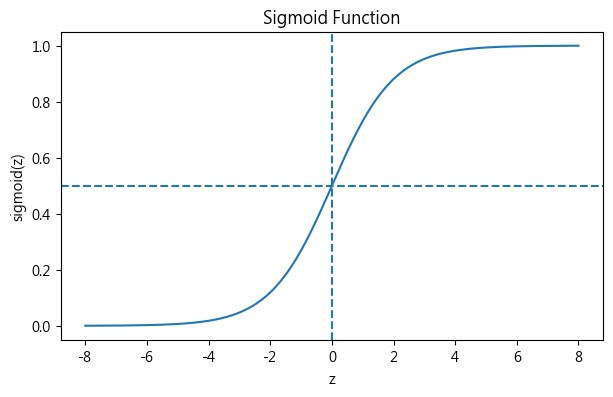

In [5]:
# ============================================================
# 3. Sigmoid 函數視覺化
# ============================================================

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_values = np.linspace(-8, 8, 200)
probabilities = sigmoid(z_values)

plt.figure(figsize=(7, 4))
plt.plot(z_values, probabilities)
plt.axhline(y=0.5, linestyle="--")
plt.axvline(x=0, linestyle="--")
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.title("Sigmoid Function")
plt.show()

## 4. 邏輯斯迴歸、正規化與模型評估

這一格用寶可夢資料示範二元分類。

目標是預測寶可夢是否具有第二屬性：

- `hasType2 = 1`：有第二屬性。
- `hasType2 = 0`：沒有第二屬性。

同時示範：

1. Accuracy、Precision、Recall、F1-score。
2. L2 正規化。
3. L1 正規化。
4. 使用新資料 `newData` 進行預測。


In [6]:
# ============================================================
# 4. 邏輯斯迴歸、正規化、模型評估、新資料預測
# ============================================================

# L2 正規化是 LogisticRegression 的常見預設形式
logistic_l2 = LogisticRegression(max_iter=1000, C=1.0)
logistic_l2.fit(X_pokemon_train_scaled, y_pokemon_train)
logistic_l2_pred = logistic_l2.predict(X_pokemon_test_scaled)

# L1 正規化需要指定 solver="liblinear"
'''
LogisticRegression 裡面的 solver 是模型係數的最佳化演算法，而不是每一種 solver 都支援 L1。
scikit-learn 文件說明，lbfgs、newton-cg、newton-cholesky、sag 主要只支援 L2 或不加 regularization；
liblinear 支援 L1 和 L2；saga 也支援 L1，並且支援 Elastic Net。
'''
logistic_l1 = LogisticRegression(max_iter=1000, C=1.0, penalty="l1", solver="liblinear")
logistic_l1.fit(X_pokemon_train_scaled, y_pokemon_train)
logistic_l1_pred = logistic_l1.predict(X_pokemon_test_scaled)

print("L2 Logistic Regression 準確率：", accuracy_score(y_pokemon_test, logistic_l2_pred))
print("L1 Logistic Regression 準確率：", accuracy_score(y_pokemon_test, logistic_l1_pred))

print("L2 Logistic Regression classification report：")
print(classification_report(y_pokemon_test, logistic_l2_pred))

print("混淆矩陣：")
confusion_result = confusion_matrix(y_pokemon_test, logistic_l2_pred)
confusion_df = pd.DataFrame(
    confusion_result,
    index=["真實：沒有第二屬性", "真實：有第二屬性"],
    columns=["預測：沒有第二屬性", "預測：有第二屬性"]
)
display(confusion_df)


print("新資料預測結果：")
# 特徵順序必須和 feature_columns 一樣：
# ["HP", "Attack", "Defense", "SpecialAtk", "SpecialDef", "Speed"]
newData = [
    [50, 55, 45, 60, 50, 60],
    [250, 250, 250, 250, 250, 250]
]
newData_scaled = pokemon_scaler.transform(newData)
new_prediction = logistic_l2.predict(newData_scaled)
new_probability = logistic_l2.predict_proba(newData_scaled)
print(new_prediction)

print("新資料預測機率：")
new_probability_df = pd.DataFrame(
    new_probability, 
    columns=["沒有第二屬性的機率", "有第二屬性的機率"]
)
display(new_probability_df)

L2 Logistic Regression 準確率： 0.6071428571428571
L1 Logistic Regression 準確率： 0.6116071428571429
L2 Logistic Regression classification report：
              precision    recall  f1-score   support

           0       0.58      0.57      0.58       105
           1       0.63      0.64      0.63       119

    accuracy                           0.61       224
   macro avg       0.61      0.61      0.61       224
weighted avg       0.61      0.61      0.61       224

混淆矩陣：


,預測：沒有第二屬性,預測：有第二屬性
真實：沒有第二屬性,60,45
真實：有第二屬性,43,76


新資料預測結果：
[0 1]
新資料預測機率：


,沒有第二屬性的機率,有第二屬性的機率
0,0.572588,0.427412
1,0.031673,0.968327


## 5. 混淆矩陣視覺化

混淆矩陣可以幫助我們觀察分類器犯錯的位置。

在二元分類中，常見四種結果：

- TP：真實為正類，模型也預測為正類。
- TN：真實為負類，模型也預測為負類。
- FP：真實為負類，但模型預測為正類。
- FN：真實為正類，但模型預測為負類。


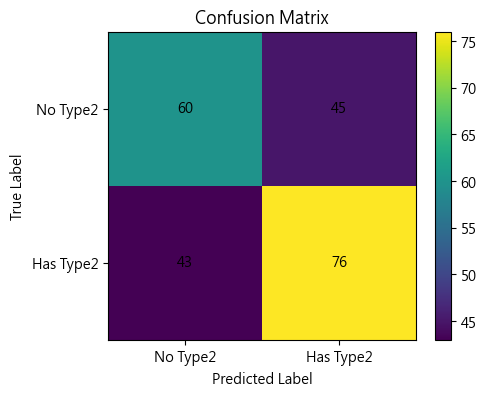

In [ ]:
# ============================================================
# 5. 使用 matplotlib 視覺化混淆矩陣
# ============================================================

plt.figure(figsize=(5, 4))
plt.imshow(confusion_result)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["No Type2", "Has Type2"])
plt.yticks([0, 1], ["No Type2", "Has Type2"])
plt.colorbar()

row_index = 0
while row_index < confusion_result.shape[0]:
    col_index = 0
    while col_index < confusion_result.shape[1]:
        plt.text(
            col_index, 
            row_index, 
            confusion_result[row_index, col_index], 
            ha="center", 
            va="center"
        )
        col_index = col_index + 1
    row_index = row_index + 1

plt.show()

## 6. 支援向量機：Linear SVM 與 Kernel SVM

SVM 的核心想法是找到能分開不同類別的分類邊界。

本章示範：

1. `LinearSVC`：線性支援向量機。
2. `SVC(kernel="linear")`：使用線性 kernel 的 SVC。
3. `SVC(kernel="rbf")`：使用 RBF kernel 處理非線性分類。


In [9]:
# ============================================================
# 6. 支援向量機 SVM
# ============================================================

linear_svc = LinearSVC(C=1.0, max_iter=5000, random_state=0)
linear_svc.fit(X_pokemon_train_scaled, y_pokemon_train)
linear_svc_pred = linear_svc.predict(X_pokemon_test_scaled)

svc_linear = SVC(kernel="linear", C=1.0)
svc_linear.fit(X_pokemon_train_scaled, y_pokemon_train)
svc_linear_pred = svc_linear.predict(X_pokemon_test_scaled)

svc_rbf = SVC(kernel="rbf", C=1.0, gamma="scale")
svc_rbf.fit(X_pokemon_train_scaled, y_pokemon_train)
svc_rbf_pred = svc_rbf.predict(X_pokemon_test_scaled)

print("LinearSVC 準確率：", accuracy_score(y_pokemon_test, linear_svc_pred))
print("SVC linear kernel 準確率：", accuracy_score(y_pokemon_test, svc_linear_pred))
print("SVC RBF kernel 準確率：", accuracy_score(y_pokemon_test, svc_rbf_pred))

print("SVC RBF kernel 前 10 筆預測：")
print(svc_rbf_pred[:10])

LinearSVC 準確率： 0.6071428571428571
SVC linear kernel 準確率： 0.6205357142857143
SVC RBF kernel 準確率： 0.6160714285714286
SVC RBF kernel 前 10 筆預測：
[0 1 1 0 1 0 1 1 1 1]


## 7. 樸素貝氏分類器

樸素貝氏分類器根據貝氏定理進行分類，常見版本包含：

1. `GaussianNB`：適合連續型特徵。
2. `MultinomialNB`：適合非負的計數型或次數型特徵，例如文字分類中的詞頻。

寶可夢能力值是非負數，因此這裡用它來示範兩種樸素貝氏分類器的操作方式。


In [10]:
# ============================================================
# 7. GaussianNB 與 MultinomialNB
# ============================================================

# GaussianNB：可以直接使用連續型特徵
gaussian_nb = GaussianNB()
gaussian_nb.fit(X_pokemon_train, y_pokemon_train)
gaussian_nb_pred = gaussian_nb.predict(X_pokemon_test)

# MultinomialNB：適合非負特徵，因此這裡使用原始能力值，不使用標準化後的資料
multinomial_nb = MultinomialNB()
multinomial_nb.fit(X_pokemon_train, y_pokemon_train)
multinomial_nb_pred = multinomial_nb.predict(X_pokemon_test)

print("GaussianNB 準確率：", accuracy_score(y_pokemon_test, gaussian_nb_pred))
print("MultinomialNB 準確率：", accuracy_score(y_pokemon_test, multinomial_nb_pred))

print("\nGaussianNB classification report：")
print(classification_report(y_pokemon_test, gaussian_nb_pred))

GaussianNB 準確率： 0.5982142857142857
MultinomialNB 準確率： 0.5267857142857143

GaussianNB classification report：
              precision    recall  f1-score   support

           0       0.57      0.61      0.59       105
           1       0.63      0.59      0.61       119

    accuracy                           0.60       224
   macro avg       0.60      0.60      0.60       224
weighted avg       0.60      0.60      0.60       224



## 8. 決策樹：Entropy、Information Gain、分類與迴歸

決策樹會不斷選擇特徵與切分條件，讓切分後的資料更「純」。

本章示範：

1. 用簡單數字理解 entropy 與 information gain。
2. 使用 `DecisionTreeClassifier` 做分類。
3. 使用 `DecisionTreeRegressor` 做迴歸，理解決策樹也可以預測連續數值。


In [11]:
import math

'''
在建立樹之前，需要先計算資料集的熵 (entropy)，以便找到最佳的分割點，根的訓練範例從 yes = 9, no = 5 開始
'''
# info([9, 5]) = entropy(9/14, 5/14) = -9/14 x log(9/14) - 5/14 x log(5/14) = 0.940
info_9_5 = -(9/14 * math.log2(9/14) + 5/14 * math.log2(5/14))
print(f"info([9, 5]) = {info_9_5}") # info([9, 5]) = 0.9402859586706311

'''
Outlook 的三個分支 (節點) 分別為 sunny, overcast, rainy，每個分支的資料集如下
'''
# info([2,3]) = entropy(2/5, 3/5) = -2/5 x log(2/5) - 3/5 x log(3/5) = 0.971
info_2_3 = -(2/5 * math.log2(2/5) + 3/5 * math.log2(3/5))
print(f"info([2, 3]) = {info_2_3}") # info([2, 3]) = 0.9709505944546686

# info([4,0]) = entropy(4/4, 0/4) = -4/4 x log(4/4) - 0/4 x log(0/4) = 0
info_4_0 = -(4/4 * math.log2(4/4))
print(f"info([4, 0]) = {info_4_0}") # info([4, 0]) = -0.0

# info([3,2]) = entropy(3/5, 2/5) = -3/5 x log(3/5) - 2/5 x log(2/5) = 0.971
info_3_2 = -(3/5 * math.log2(3/5) + 2/5 * math.log2(2/5))
print(f"info([3, 2]) = {info_3_2}") # info([3, 2]) = 0.9709505944546686

'''
計算三個分支的平均資訊熵
'''
# info([2,3], [4,0], [3,2]) = 5/14 x 0.971 + 4/14 x 0 + 5/14 x 0.971 = 0.693
info_2_3_4_0_3_2 = 5/14 * info_2_3 + 4/14 * info_4_0 + 5/14 * info_3_2
print(f"info([2, 3], [4, 0], [3, 2]) = {info_2_3_4_0_3_2}") # info([2, 3], [4, 0], [3, 2]) = 0.6935361388961918

'''
計算 information gain
'''
# info([9, 5]) - info([2,3], [4,0], [3,2]) = 0.940 - 0.693 = 0.247
info_gain = info_9_5 - info_2_3_4_0_3_2
print(f"Information Gain = {info_gain}") # Information Gain = 0.24674981977443933

info([9, 5]) = 0.9402859586706311
info([2, 3]) = 0.9709505944546686
info([4, 0]) = -0.0
info([3, 2]) = 0.9709505944546686
info([2, 3], [4, 0], [3, 2]) = 0.6935361388961918
Information Gain = 0.24674981977443933


In [ ]:
# ============================================================
# 9. 決策樹：entropy / information gain / 分類 / 迴歸
# ============================================================

# 定義一個函數，從正例和負例的計數中計算熵
def entropy_from_counts(count_1, count_0):
    total = count_1 + count_0

    if total == 0:
        return 0

    p1 = count_1 / total
    p0 = count_0 / total

    result = 0

    for p in [p1, p0]:
        if p > 0:
            result = result - p * math.log2(p)

    return result

# 經典天氣範例：原始資料 yes=9, no=5
original_entropy = entropy_from_counts(9, 5)

# Outlook 分成三群：
# sunny: 2 yes, 3 no
# overcast: 4 yes, 0 no
# rainy: 3 yes, 2 no
sunny_entropy = entropy_from_counts(2, 3)
overcast_entropy = entropy_from_counts(4, 0)
rainy_entropy = entropy_from_counts(3, 2)

weighted_entropy = (5 / 14) * sunny_entropy + (4 / 14) * overcast_entropy + (5 / 14) * rainy_entropy
information_gain = original_entropy - weighted_entropy

print("原始 entropy：", round(original_entropy, 4))
print("Outlook 分割後的加權 entropy：", round(weighted_entropy, 4))
print("Information Gain：", round(information_gain, 4))

# Gini index 小範例
p_positive = 9 / 14
p_negative = 5 / 14
gini_value = 1 - p_positive ** 2 - p_negative ** 2
print("原始 Gini index：", round(gini_value, 4))

# ---------- 決策樹分類 ----------
tree_classifier = DecisionTreeClassifier(
    criterion="entropy",# 沒寫就會是預設 gini index
    max_depth=3,# 要有幾層
    random_state=0
)
tree_classifier.fit(X_pokemon_train, y_pokemon_train)
tree_classifier_pred = tree_classifier.predict(X_pokemon_test)

print("DecisionTreeClassifier 準確率：", accuracy_score(y_pokemon_test, tree_classifier_pred))

# ---------- 決策樹迴歸 ----------
# 這裡只是示範「決策樹也可以做迴歸」：
# 用 HP、Attack、Defense、SpecialAtk、SpecialDef 預測 Speed。
tree_regression_data = pokemon_data.copy()
tree_regression_features = ["HP", "Attack", "Defense", "SpecialAtk", "SpecialDef"]
X_tree_regression = tree_regression_data[tree_regression_features]
y_tree_regression = tree_regression_data["Speed"]

X_tree_reg_train, X_tree_reg_test, y_tree_reg_train, y_tree_reg_test = train_test_split(
    X_tree_regression,
    y_tree_regression,
    test_size=0.25,
    random_state=0
)

tree_regressor = DecisionTreeRegressor(max_depth=3, random_state=0)
tree_regressor.fit(X_tree_reg_train, y_tree_reg_train)
tree_regression_pred = tree_regressor.predict(X_tree_reg_test)

print("DecisionTreeRegressor MAE：", round(mean_absolute_error(y_tree_reg_test, tree_regression_pred), 4))

原始 entropy： 0.9403
Outlook 分割後的加權 entropy： 0.6935
Information Gain： 0.2467
原始 Gini index： 0.4592
DecisionTreeClassifier 準確率： 0.6116071428571429
DecisionTreeRegressor MAE： 20.7637


## 9. 隨機森林與 K 最近鄰居

最後示範兩類常見分類器：

1. **Random Forest**：整合多棵決策樹，通常比單棵決策樹更穩定。
2. **KNN**：根據距離最近的 K 個鄰居投票分類。
3. **Radius Neighbors**：不是固定找 K 個鄰居，而是找指定半徑內的所有鄰居。

這一格也會用 `matplotlib` 畫出隨機森林的特徵重要性。


RandomForestClassifier 準確率： 0.6116071428571429
KNeighborsClassifier 準確率： 0.53125
RadiusNeighborsClassifier 準確率： 0.5803571428571429


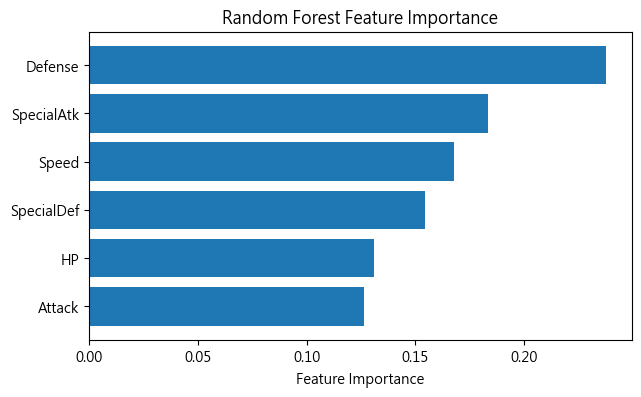

In [ ]:
# ============================================================
# 10. Random Forest、KNN、Radius Neighbors、特徵重要性視覺化
# ============================================================

random_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    max_features="sqrt",
    random_state=0
)
random_forest.fit(X_pokemon_train, y_pokemon_train)
random_forest_pred = random_forest.predict(X_pokemon_test)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_pokemon_train_scaled, y_pokemon_train)
knn_pred = knn_model.predict(X_pokemon_test_scaled)

radius_model = RadiusNeighborsClassifier(radius=3.0, outlier_label=0)
radius_model.fit(X_pokemon_train_scaled, y_pokemon_train)
radius_pred = radius_model.predict(X_pokemon_test_scaled)

print("RandomForestClassifier 準確率：", accuracy_score(y_pokemon_test, random_forest_pred))
print("KNeighborsClassifier 準確率：", accuracy_score(y_pokemon_test, knn_pred))
print("RadiusNeighborsClassifier 準確率：", accuracy_score(y_pokemon_test, radius_pred))

# ---------- 隨機森林特徵重要性 ----------
importances = random_forest.feature_importances_ # 如果有樹狀的,通常都會有這個feature_importances_
sorted_index = np.argsort(importances)

plt.figure(figsize=(7, 4))
plt.barh(np.array(feature_columns)[sorted_index], importances[sorted_index])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()